In [1]:
import os
import glob
import gc
import random

import numpy as np
import pandas as pd

from scipy.stats import median_abs_deviation, percentileofscore
import torch

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import scvi

import pegasus as pg
from pegasusio import UnimodalData, MultimodalData

from tqdm import tqdm

%matplotlib inline

sc.settings.n_jobs = 25

random.seed(0)
np.random.seed(0)
sc.settings.seed = 0

torch.set_float32_matmul_precision("high")

/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)
/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)


In [2]:
## Import All Datasets ##

# capture file paths
FILE_PATHS = glob.glob('/mnt/sdb/scz_meta_analysis_processed/*/anndata_objs/*qc.h5ad')
FILE_PATHS = [file_path for file_path in FILE_PATHS if (('shin_thal' not in file_path) and ('shin_qc' not in file_path))]

# import anndata objects into list
ANNDATA_LIST = [sc.read_h5ad(file_path) for file_path in FILE_PATHS]

# concatenate
adata = sc.concat(ANNDATA_LIST, axis='obs', join='outer')

# recovery memory
del ANNDATA_LIST
del adata.obsm
del adata.uns
gc.collect()

44082

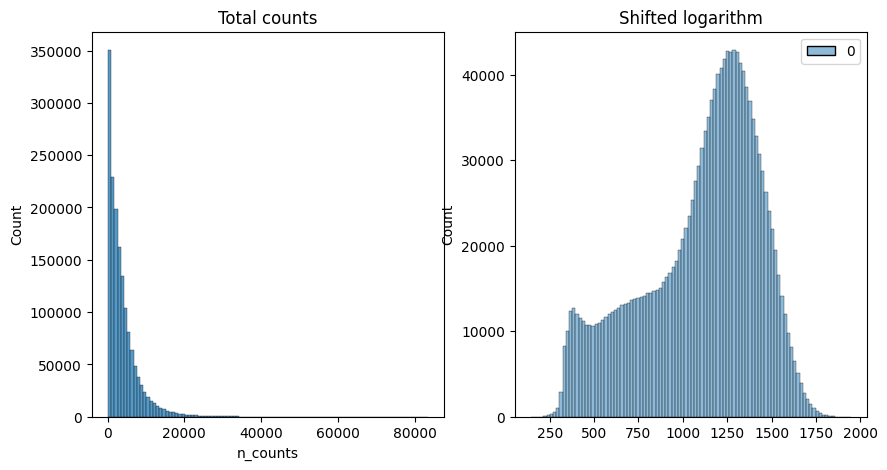

In [3]:
## Log Normalization ##

# normalize 
scales_counts = sc.pp.normalize_total(adata, layer='raw_counts', target_sum=None, inplace=False)

# log1p transform
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

# set X as log1p normed counts
adata.X = adata.layers["log1p_norm"]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.obs["n_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

In [4]:
## Map NCBI Gene Names w/Prasanth's File ##

# load prasanth's annotation file
prasanth_annot = pd.read_csv('/home/deepak/datasets/annotations/all_genes_EnsemblInfo_104.csv')

# merge prasanth's gene info into the var dataframe
adata.var['ensembl_gene_id'] = adata.var.index
adata.var = adata.var.merge(prasanth_annot, left_on='ensembl_gene_id', right_on='ensembl_gene_id', how='left')
adata.var.chromosome_name = adata.var.chromosome_name.astype('str')

# fix gene name that is NaN
adata.var.loc[adata.var['hgnc_symbol'].isna(),'hgnc_symbol'] = adata.var.loc[adata.var['hgnc_symbol'].isna(),'ensembl_gene_id']

#reset the index as the hgnc_symbol
adata.var.index = adata.var['hgnc_symbol']
adata.var.index.name = None

#some ensembls map to same hgnc so we make them unique
adata.var_names_make_unique(join='#')

gc.collect()

/tmp/ipykernel_137604/2840611834.py:4: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  prasanth_annot = pd.read_csv('/home/deepak/datasets/annotations/all_genes_EnsemblInfo_104.csv')


163

In [5]:
## Set Up QC Metrics ##

# filter on robust genes
pg.identify_robust_genes(adata, percent_cells=0.05)
adata = adata[:,adata.var['robust']].copy()
gc.collect()

# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

# add protein_coding genes
adata.var['protein_coding'] = adata.var['gene_biotype'].apply(lambda x: True if 'protein_coding' == x else False)
adata.var['protein_coding'] = adata.var['protein_coding'].astype('bool')

# define mitocarta_genes
mitocarta_df = pd.read_csv('/home/deepak/datasets/annotations/Human.MitoCarta3.0.csv')
adata.var['mitocarta'] = [True if x in list(mitocarta_df['Symbol']) else False for x in adata.var.index]

# define robust_protein_coding genes (exclude ribosomal (RPL,RPS), mitochondrial, or mitocarta genes
adata.var['robust_protein_coding'] = adata.var['robust'] & adata.var['protein_coding']
adata.var.loc[adata.var.ribo, 'robust_protein_coding'] = False
adata.var.loc[adata.var.mt, 'robust_protein_coding'] = False
adata.var.loc[adata.var.mitocarta, 'robust_protein_coding'] = False

# define robust_protein_coding_autosome genes (exclude ribosomal (RPL,RPS), mitochondrial, or mitocarta genes
adata.var['autosome'] = adata.var.chromosome_name.isin([str(i) for i in range(1,23)])
adata.var['robust_protein_coding_autosome'] = adata.var['robust_protein_coding'] & adata.var['autosome'] 
pg.qc_metrics(UnimodalData(adata), mito_prefix='MT-')

2026-02-23 21:36:44,163 - pegasus.tools.preprocessing - INFO - After filtration, 23954/23959 genes are kept. Among 23954 genes, 19264 genes are robust.
2026-02-23 21:36:44,164 - pegasus.tools.preprocessing - INFO - Function 'identify_robust_genes' finished in 46.70s.


In [6]:
## Batched HVG Selection ##

# calc score requires a float downcast for some reason
adata.X = adata.X.astype('float32')
pg.calc_signature_score(UnimodalData(adata), 'cell_cycle_human')

# calculate HVGs on a protein_coding_autosomal only gene list
adata_hvg = adata[:,adata.var.robust_protein_coding_autosome].copy()
hvg = sc.pp.highly_variable_genes(adata_hvg, layer='log1p_norm', n_top_genes=3000, inplace=False, subset=False, batch_key='Manuscript')
hvg_list = adata_hvg.var.index[hvg.highly_variable].tolist()
del adata_hvg
gc.collect()

# apply that HVG list to your original anndata object
adata.var['highly_variable_features'] = False
adata.var['highly_variable_features'] = adata.var.index.isin(hvg_list)

2026-02-23 21:37:48,836 - pegasus.tools.utils - INFO - Loaded signatures from GMT file /home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/pegasus/data_files/cell_cycle_human.gmt.
2026-02-23 21:37:48,838 - pegasus.tools.signature_score - INFO - Signature G1/S: 43 out of 43 genes are used in signature score calculation.
2026-02-23 21:37:48,839 - pegasus.tools.signature_score - WARNING - Signature key G1/S exists in data.obs, the existing content will be overwritten!
2026-02-23 21:37:53,074 - pegasus.tools.signature_score - INFO - Signature G2/M: 54 out of 54 genes are used in signature score calculation.
2026-02-23 21:37:53,075 - pegasus.tools.signature_score - WARNING - Signature key G2/M exists in data.obs, the existing content will be overwritten!
2026-02-23 21:37:57,961 - pegasus.tools.signature_score - INFO - Function 'calc_signature_score' finished in 18.38s.


In [7]:
## Prepare Variables for Unsupervised Integration ##

## Use Imputed Sex ##

adata.obs['Sex'] = adata.obs['Sex'].replace({'M': 'Male', 'F': 'Female'}).astype('str')
adata.obs.loc[adata.obs['Sex'] == 'nan', 'Sex'] = adata.obs['Imputed_Sex'].str.replace('Imputed ', '')

## Make Day Float ##
adata.obs['Day'] = adata.obs['Day'].astype('float')

In [8]:
## Setup Model & Begin Training ##

scvi.model.SCVI.setup_anndata(adata, layer="raw_counts", categorical_covariate_keys=["Donor", "Manuscript"],
                              continuous_covariate_keys=["n_counts", "percent_mito", "Day"])

model = scvi.model.SCVI(adata)

model.train()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/5 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.


In [ ]:
## Save and Loading ##

model_dir = os.path.join(save_dir.name, "scvi_model")
model.save(model_dir, overwrite=True)

model = scvi.model.SCVI.load(model_dir, adata=adata)

In [ ]:
## Save Model Representation ##

adata.obsm["X_scVI"] = model.get_latent_representation()

adata.layers["scvi_normalized"] = model.get_normalized_expression(library_size=10e4)

pg.pca(adata, n_components=30)

In [ ]:
## Visualize Without Batch Correction ##

pg.regress_out(adata, ['n_counts', 'percent_mito'])
pg.neighbors(adata, rep='pca_regressed', use_cache=False, dist='l2', K=100, n_comps=30)
pg.umap(adata, rep='pca_regressed', n_neighbors=15, rep_ncomps=30)

In [ ]:
## Visualize With Harmony Only Batch Correction ##

pg.regress_out(adata, ['n_counts', 'percent_mito'])
pg.neighbors(adata, rep='pca_regressed_harmony', use_cache=False, dist='l2', K=100, n_comps=30)
pg.run_harmony(notaras_adata, batch=['Donor'], rep='pca_regressed', max_iter_harmony=20, n_comps=30)
pg.umap(adata, rep='pca_regressed_harmony', n_neighbors=15, rep_ncomps=30)

In [ ]:
## Visualize With Batch Correction ##

# use scVI latent space for UMAP generation
pg.neighbors(adata, rep='X_scVI', use_cache=False, dist='l2', K=100, n_comps=30)
pg.umap(adata, rep='pca_regressed_harmony', n_neighbors=15, rep_ncomps=30)